# Jet Mass Reconstruction
Evaluate a trained hadron-to-parton regression model: run inference, compute true vs. reconstructed jet masses, compute per-event EMD, and plot results.

## Imports

In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vector                                  # pip install vector
from sklearn.preprocessing import StandardScaler
from torch import nn

try:
    import energyflow                          # pip install energyflow
    _HAS_EF = True
except ImportError:
    _HAS_EF = False
    print("WARNING: energyflow not found — EMD panel will be skipped. "
          "Install with: pip install energyflow")

## Configuration
Edit these paths/settings before running.

In [3]:
DATA_DIR = os.path.abspath(".")

PARTON_CSV = f"{DATA_DIR}/parton_level_filtered.csv"
HADRON_CSV = f"{DATA_DIR}/hadron_level_filtered.csv"
MODEL_PTH   = f"{DATA_DIR}/model_filtered.pth"

MAX_EVENTS     = 8000                        # set to e.g. 8000 to cap, None = all
BINS           = 60                          # number of histogram bins
MASS_MAX       = 700                         # fixed x-axis upper limit [GeV] — same for all runs
EMD_MAX_EVENTS = 5000                        # EMD is O(n^2) per pair — cap for speed

## Model
Must match the architecture used during training exactly.

In [4]:
class Net(nn.Module):
    def __init__(self, input_shape):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_shape, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 256)
        self.fc4 = nn.Linear(256, 128)
        self.fc5 = nn.Linear(128, 60)   # 1 multiplicity + 20 partons x 3 features

    def forward(self, x):
        x = self.fc1(x).relu()
        x = self.fc2(x).relu()
        x = self.fc3(x).relu()
        x = self.fc4(x).relu()
        x = self.fc5(x)
        return x

## CSV Loader
Auto-detects indexed vs. non-indexed format.

In [5]:
def load_csv(path, expected_cols=None):
    """
    Loads a jet CSV and returns a float32 numpy array of shape (N_jets, N_features).

    expected_cols: the exact number of feature columns we need (read from the
                   model checkpoint before calling this).  If the CSV has one
                   extra column at the front, it is stripped — no fragile
                   content-based heuristic needed.
    """
    df = pd.read_csv(path, header=None)

    # Drop columns that are entirely NaN (caused by trailing commas)
    df = df.dropna(axis=1, how='all')
    df = df.fillna(0.0)

    if expected_cols is not None:
        if df.shape[1] == expected_cols + 1:
            # One extra column at the front — must be the row index, strip it
            print(f"  [{path.split('/')[-1]}]  {df.shape[1]} cols detected, "
                  f"stripping leading index column -> {expected_cols} features")
            df = df.iloc[:, 1:]
        elif df.shape[1] == expected_cols:
            pass   # already correct
        else:
            raise ValueError(
                f"{path}: expected {expected_cols} or {expected_cols+1} columns, "
                f"got {df.shape[1]}."
            )
    else:
        # No hint given — fall back to sequential-index heuristic
        first_col = pd.to_numeric(df.iloc[:, 0], errors='coerce')
        is_index  = (
            first_col.notna().all()
            and (first_col.astype(int).values == np.arange(len(df))).all()
        )
        if is_index:
            print(f"  [{path.split('/')[-1]}]  detected index column, stripping it.")
            df = df.iloc[:, 1:]

    print(f"  [{path.split('/')[-1]}]  {len(df)} jets  x  {df.shape[1]} features")
    return df.values.astype(np.float32)

## Physics Helpers
Jet invariant mass and particle parsing using the `vector` library.

In [6]:
def parse_particles(row, n_particles=None):
    """Return (N, 3) array of [pT, eta, phi] for non-zero pT particles."""
    max_triplets = int(n_particles) if n_particles is not None else len(row) // 3
    particles = []
    for i in range(max_triplets):
        base = i * 3
        if base + 2 >= len(row):
            break
        pT, eta, phi = float(row[base]), float(row[base + 1]), float(row[base + 2])
        if pT > 0.0:
            particles.append([pT, eta, phi])
    return np.array(particles, dtype=np.float64) if particles else np.zeros((1, 3))


def jet_mass(row, n_particles=None):
    jet = vector.obj(px=0.0, py=0.0, pz=0.0, energy=0.0)

    if n_particles is not None:
        max_triplets = int(n_particles)
    else:
        max_triplets = len(row) // 3

    for i in range(max_triplets):
        base = i * 3
        if base + 2 >= len(row):
            break
        pT, eta, phi = float(row[base]), float(row[base + 1]), float(row[base + 2])
        if pT <= 0.0:
            continue
        particle = vector.obj(pt=pT, eta=eta, phi=phi, mass=0.0)
        jet = jet + particle

    return float(jet.mass)

## 1. Load Checkpoint & CSVs
Read the checkpoint first to learn expected input/output dimensions — this is the ground truth, the CSV must conform to the model, not vice versa.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

_state = torch.load(MODEL_PTH, map_location=device)
HADRON_COLS = int(_state["fc1.weight"].shape[1])   # model input  dim
PARTON_COLS = int(_state["fc5.weight"].shape[0])   # model output dim

print(f"Checkpoint expects  : {HADRON_COLS} hadron features  |  {PARTON_COLS} parton features")

print(f"\nLoading hadron CSV : {HADRON_CSV}")
x_raw = load_csv(HADRON_CSV, expected_cols=HADRON_COLS)

print(f"Loading parton CSV : {PARTON_CSV}")
y_raw = load_csv(PARTON_CSV, expected_cols=PARTON_COLS)

print(f"\nHadron shape : {x_raw.shape}")
print(f"Parton shape : {y_raw.shape}")

if MAX_EVENTS is not None:
    x_raw = x_raw[:MAX_EVENTS]
    y_raw = y_raw[:MAX_EVENTS]
    print(f"Capped to {MAX_EVENTS} events")

assert len(x_raw) == len(y_raw), (
    f"Row count mismatch — hadron: {len(x_raw)}, parton: {len(y_raw)}"
)

Using device: cpu
Checkpoint expects  : 90 hadron features  |  60 parton features

Loading hadron CSV : /Users/michaeltaleb/Desktop/Rythia/hadron_level_filtered.csv
  [hadron_level_filtered.csv]  88310 jets  x  90 features
Loading parton CSV : /Users/michaeltaleb/Desktop/Rythia/parton_level_filtered.csv
  [parton_level_filtered.csv]  88310 jets  x  60 features

Hadron shape : (88310, 90)
Parton shape : (88310, 60)
Capped to 8000 events


## 2. Replicate Training-Time Scaling
The training script fit the scalers on only the first 8000 events with `shuffle=False`, so we must do exactly the same — otherwise the mean/std used to inverse-transform predictions will be slightly off.

In [8]:
N_TRAIN = 8000

scx = StandardScaler()
scx.fit(x_raw[:N_TRAIN])
x_scaled = scx.transform(x_raw)

scy = StandardScaler()
scy.fit(y_raw[:N_TRAIN])

,copy,True
,with_mean,True
,with_std,True


## 3. Load Model & Run Inference

In [9]:
model = Net(input_shape=x_scaled.shape[1])
model.load_state_dict(torch.load(MODEL_PTH, map_location=device))
model.to(device)
model.eval()
print(f"\nModel loaded from  : {MODEL_PTH}  (input dim = {x_scaled.shape[1]})")

x_tensor = torch.tensor(x_scaled, dtype=torch.float32).to(device)

with torch.no_grad():
    y_pred_scaled = model(x_tensor).cpu().numpy()

y_pred = scy.inverse_transform(y_pred_scaled)
print(f"Inference done.  Output shape: {y_pred.shape}")


Model loaded from  : /Users/michaeltaleb/Desktop/Rythia/model_filtered.pth  (input dim = 90)
Inference done.  Output shape: (8000, 60)


Wrap phi back to `[-pi, pi]` — the model is unconstrained and can predict phi outside this range, which causes 4-vectors to not cancel -> blown mass. Phi is every 3rd column starting at index 2: cols 2, 5, 8, ...

In [ ]:
phi_cols = list(range(2, y_pred.shape[1], 3))
y_pred[:, phi_cols] = (y_pred[:, phi_cols] + np.pi) % (2 * np.pi) - np.pi
print(f"Phi wrapped to [-pi, pi] for {len(phi_cols)} columns.")

## 4. Compute Jet Masses (`vector`)
For true jets: skip `pT<=0` (padding is genuinely zero). For reconstructed jets: pass the TRUE multiplicity from `y_raw` so that phantom non-zero pT values in padding slots are not included in the mass. The model was never trained to output exactly 0 for unused slots, so without this cap the reconstructed mass is systematically inflated.

In [10]:
print("\nComputing jet masses with `vector` ...")
true_mults   = y_raw[:, 0]   # true multiplicity, used to cap reconstructed jets
true_masses  = np.array([jet_mass(row)
                         for row in y_raw],
                        dtype=np.float32)
recon_masses = np.array([jet_mass(pred_row, n_particles=n)
                         for pred_row, n in zip(y_pred, true_mults)],
                        dtype=np.float32)

print(f"\nTrue  parton mass — mean: {true_masses.mean():.2f}  std: {true_masses.std():.2f}  "
      f"median: {np.median(true_masses):.2f}  max: {true_masses.max():.2f}  GeV")
print(f"Recon parton mass — mean: {recon_masses.mean():.2f}  std: {recon_masses.std():.2f}  "
      f"median: {np.median(recon_masses):.2f}  max: {recon_masses.max():.2f}  GeV")


Computing jet masses with `vector` ...

True  parton mass — mean: 62.85  std: 37.78  median: 56.45  max: 601.04  GeV
Recon parton mass — mean: 142.00  std: 104.50  median: 122.54  max: 1196.26  GeV


## 5. Compute Per-Event EMD

In [11]:
emds = None
if _HAS_EF:
    n_emd = min(EMD_MAX_EVENTS, len(y_raw))
    print(f"\nComputing EMD for {n_emd} events (R=1.0) ...")
    emds = np.empty(n_emd, dtype=np.float32)
    for i in range(n_emd):
        ev_true  = parse_particles(y_raw[i])
        ev_recon = parse_particles(y_pred[i], n_particles=true_mults[i])
        emds[i]  = energyflow.emd.emd(ev_true, ev_recon, R=1.0)
        if (i + 1) % 500 == 0:
            print(f"  {i+1}/{n_emd} done")
    print(f"EMD — mean: {emds.mean():.4f}  std: {emds.std():.4f}  "
          f"median: {np.median(emds):.4f}  max: {emds.max():.4f}")


Computing EMD for 5000 events (R=1.0) ...
  500/5000 done
  1000/5000 done
  1500/5000 done
  2000/5000 done
  2500/5000 done
  3000/5000 done
  3500/5000 done
  4000/5000 done
  4500/5000 done
  5000/5000 done
EMD — mean: 444.4572  std: 549.5691  median: 297.1074  max: 6457.9395


## 6. Plot
Fixed axis range keeps all plots on the same scale for easy comparison — adjust `MASS_MAX` in the configuration cell if needed.

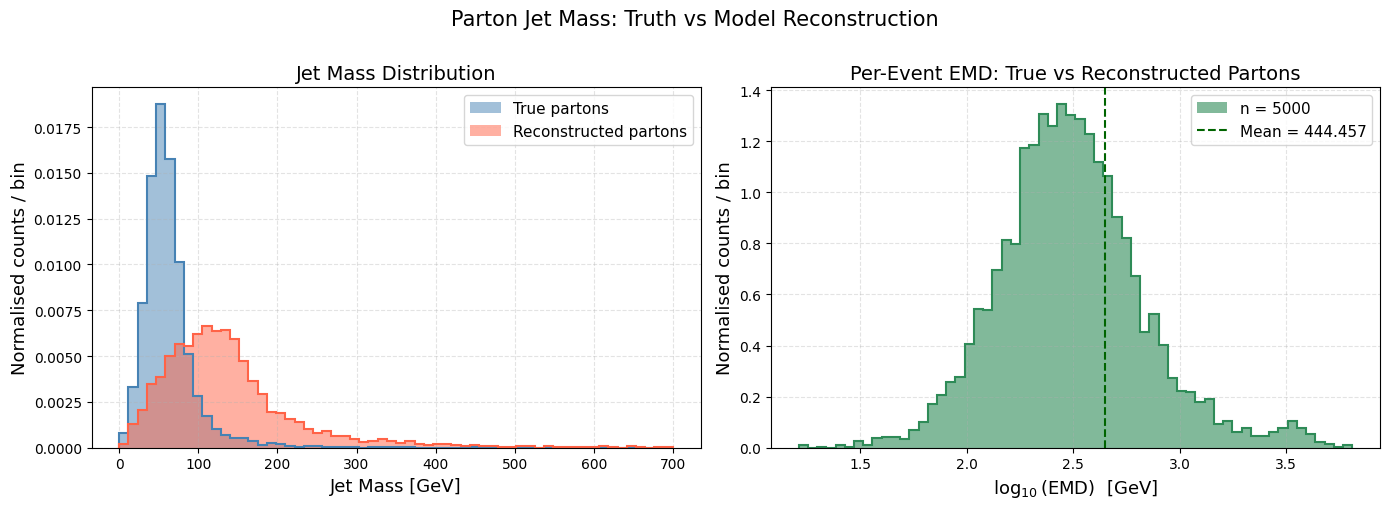

In [13]:
upper = float(MASS_MAX)
bins  = np.linspace(0.0, upper, BINS + 1)

ncols = 2 if emds is not None else 1
fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
axes = [axes] if ncols == 1 else axes
ax1 = axes[0]

# Left panel: normalised overlaid histograms
ax1.hist(true_masses,  bins=bins, density=True, alpha=0.50,
         color="steelblue", histtype="stepfilled", label="True partons")
ax1.hist(recon_masses, bins=bins, density=True, alpha=0.50,
         color="tomato",    histtype="stepfilled", label="Reconstructed partons")
ax1.hist(true_masses,  bins=bins, density=True,
         color="steelblue", histtype="step", linewidth=1.5)
ax1.hist(recon_masses, bins=bins, density=True,
         color="tomato",    histtype="step", linewidth=1.5)
ax1.set_xlabel("Jet Mass [GeV]", fontsize=13)
ax1.set_ylabel("Normalised counts / bin", fontsize=13)
ax1.set_title("Jet Mass Distribution", fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.35)

if emds is not None:
    ax2 = axes[1]
    log_emds = np.log10(emds + 1e-8)
    ax2.hist(log_emds, bins=60, density=True, alpha=0.6,
             color="seagreen", histtype="stepfilled", label=f"n = {len(emds)}")
    ax2.hist(log_emds, bins=60, density=True,
             color="seagreen", histtype="step", linewidth=1.5)
    ax2.axvline(np.log10(emds.mean()), color="darkgreen", linestyle="--", linewidth=1.5,
                label=f"Mean = {emds.mean():.3f}")
    ax2.set_xlabel(r"$\log_{10}$(EMD)  [GeV]", fontsize=13)
    ax2.set_ylabel("Normalised counts / bin", fontsize=13)
    ax2.set_title("Per-Event EMD: True vs Reconstructed Partons", fontsize=14)
    ax2.legend(fontsize=11)
    ax2.grid(True, linestyle="--", alpha=0.35)

plt.suptitle("Parton Jet Mass: Truth vs Model Reconstruction", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()